# Hierarchical BH Mergers in a Single Star Cluster

Demonstrates `HierarchicalMergersInCluster` — hierarchical merger
simulations for a single cluster specified by its mass ($M_{\rm cl}$)
and half-mass radius ($r_h$). 1G BH masses come from Kroupa IMF +
stellar evolution at a given metallicity $Z$.

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

from gwGenealogy.core import HierarchicalMergersInCluster
from gwGenealogy.hosts.star_clusters import Mcl_rh_to_vescape
from gwGenealogy.utils import set_rcparams
import matplotlib.pyplot as plt
import numpy as np

set_rcparams()


lal.MSUN_SI != Msun


## 1. Basic usage

Specify the cluster via `Mcl` and `rh`. The escape velocity is computed
automatically via the virial theorem:
$v_{\rm esc} = 2\sqrt{0.4\,G\,M_{\rm cl}/r_h}$.

In [2]:
Mcl = 1e6   # cluster mass [Msun]
rh = 2.0    # half-mass radius [pc]

v_esc = Mcl_rh_to_vescape(Mcl, rh)
print(f"Cluster: Mcl = {Mcl:.1e} Msun, rh = {rh} pc")
print(f"Escape velocity: {v_esc:.1f} km/s")

Cluster: Mcl = 1.0e+06 Msun, rh = 2.0 pc
Escape velocity: 58.7 km/s


In [3]:
sim = HierarchicalMergersInCluster(
    Mcl=Mcl, rh=rh, Z=0.005, stellar_model='SEVN_delayed',
    chi_max=0.2, max_gen=5, kick_model='gwmodel', seed=42)
print(sim)
data = sim.simulate(verbose=True)

HierarchicalMergersInCluster(Mcl=1.0e+06, rh=2.0, v_esc=58.7 km/s, Z=0.005, model=SEVN_delayed, kick=gwmodel)
1g: 2946 BHs (Mcl=1.0e+06 Msun, rh=2.0 pc, v_esc=58.7 km/s, Z=0.005, model=SEVN_delayed)


2g: 489 retained, m_med=30.6 Msun, chi_med=0.28
3g: 117 retained, m_med=38.8 Msun, chi_med=0.34
4g: 24 retained, m_med=40.1 Msun, chi_med=0.32
5g: 9 retained, m_med=50.2 Msun, chi_med=0.42


/Users/tousifislam/Research/projects/stupid/gwGenealogy/gwGenealogy/core/hierarchical.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


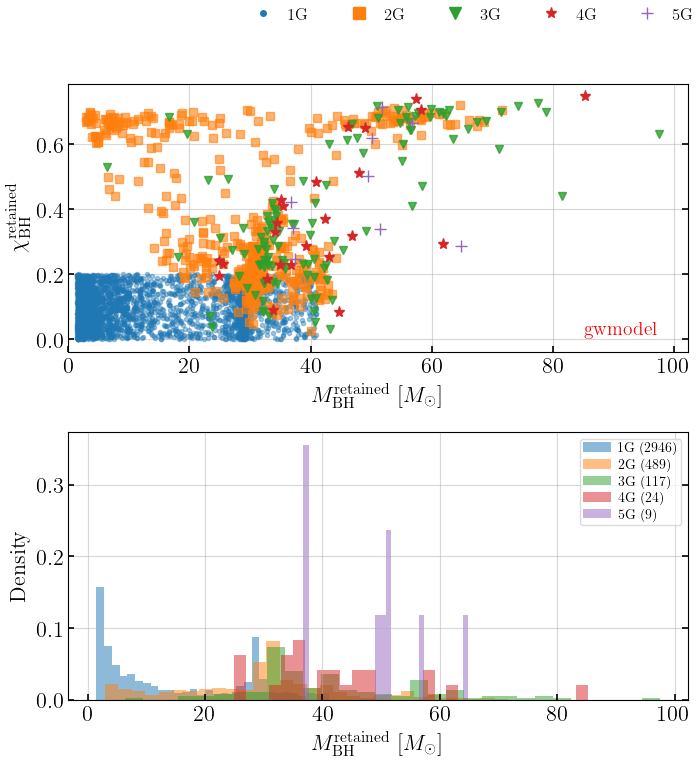

In [4]:
fig, axes = sim.plot_generations(data)
plt.show()

## 2. Evolving escape velocity

With `evolve_v_esc=True`, the cluster loses mass each time a remnant is
ejected, and $v_{\rm esc}$ is updated as:
$$v_{\rm esc}(g) = v_{\rm esc,0} \left(1 - \frac{M_{\rm ejected}}{M_{\rm cl}}\right)^{1/3}$$

Since the escape velocity only drops *after* ejections occur, the 2G
population (first generation of mergers) is identical. The effect
grows with each subsequent generation as the cluster depletes.

In [5]:
sim_evolve = HierarchicalMergersInCluster(
    Mcl=Mcl, rh=rh, Z=0.005, stellar_model='SEVN_delayed',
    chi_max=0.2, max_gen=5, evolve_v_esc=True,
    kick_model='gwmodel', seed=42, n_samples=15000)
print(sim_evolve)
data_evolve = sim_evolve.simulate(verbose=True)

HierarchicalMergersInCluster(Mcl=1.0e+06, rh=2.0, v_esc=58.7 km/s (evolving), Z=0.005, model=SEVN_delayed, kick=gwmodel)
1g: 15000 BHs (Mcl=1.0e+06 Msun, rh=2.0 pc, v_esc=58.7 km/s, Z=0.005, model=SEVN_delayed)
2g: 2555 retained, v_esc=55.9 km/s, m_med=30.5 Msun, chi_med=0.30
3g: 564 retained, v_esc=53.9 km/s, m_med=38.3 Msun, chi_med=0.42
4g: 147 retained, v_esc=53.3 km/s, m_med=50.2 Msun, chi_med=0.51
5g: 44 retained, v_esc=53.1 km/s, m_med=63.2 Msun, chi_med=0.55


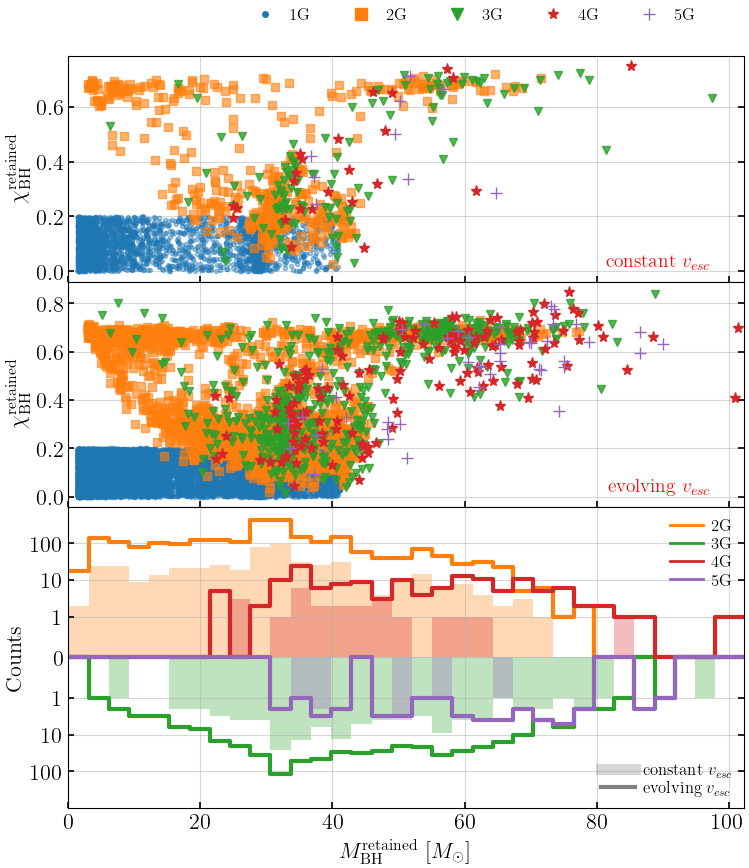

In [6]:
fig, axes = sim.plot_generations(
    data, compare_data=data_evolve,
    label='constant $v_{esc}$', compare_label='evolving $v_{esc}$')
plt.show()

In [7]:
print(f"{'Gen':>5s} {'constant':>10s} {'evolving':>10s} {'diff':>8s}")
for g in range(1, sim.max_gen + 1):
    nc = len(data[g]['m'])
    ne = len(data_evolve[g]['m'])
    print(f"{g:>3d}G {nc:>10d} {ne:>10d} {ne - nc:>+8d}")

  Gen   constant   evolving     diff
  1G       2946      15000   +12054
  2G        489       2555    +2066
  3G        117        564     +447
  4G         24        147     +123
  5G          9         44      +35


## 3. Comparing different clusters

Sweep over cluster mass to see how $v_{\rm esc}$ (and hence retention)
varies.

In [8]:
cluster_masses = [1e4, 1e5, 1e6, 1e7]
rh_fixed = 2.0

sweep_results = {}
for Mcl_i in cluster_masses:
    sim_i = HierarchicalMergersInCluster(
        Mcl=Mcl_i, rh=rh_fixed, Z=0.005, max_gen=5,
        kick_model='gwmodel', seed=42)
    sweep_results[Mcl_i] = sim_i.simulate()
    counts = [len(sweep_results[Mcl_i][g]['m']) for g in range(1, 6)]
    print(f"Mcl={Mcl_i:.0e}, v_esc={sim_i.v_esc_0:.1f} km/s: {counts}")

[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
Mcl=1e+04, v_esc=5.9 km/s: [2946, 20, 0, 0, 0]
[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
Mcl=1e+05, v_esc=18.6 km/s: [2946, 126, 8, 1, 0]
[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
Mcl=1e+06, v_esc=58.7 km/s: [2946, 489, 117, 24, 9]
[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
Mcl=1e+07, v_esc=185.5 km/s: [2946, 1158, 514, 198, 79]


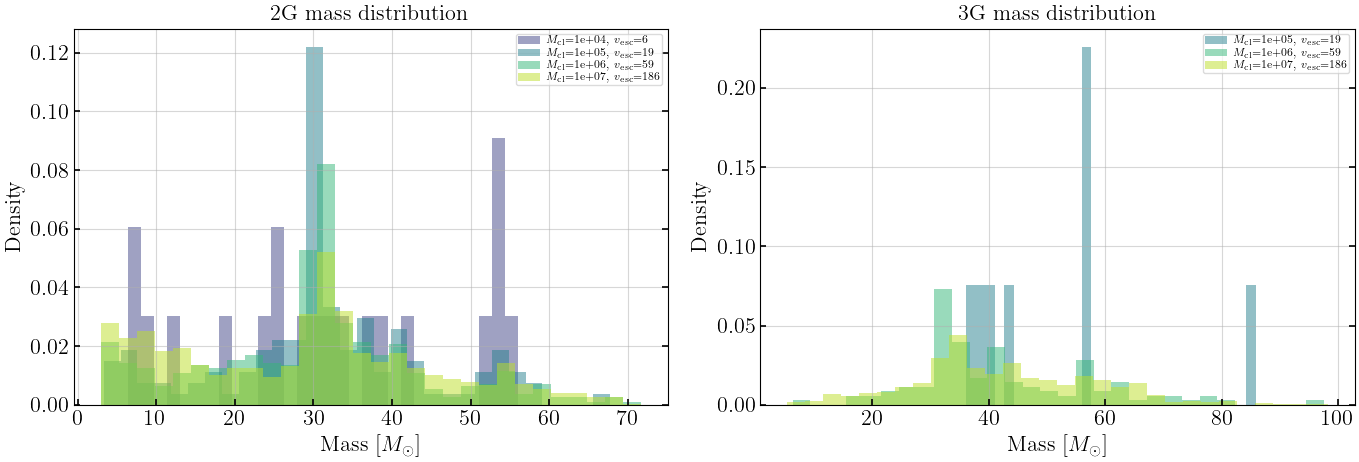

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cluster_masses)))

for (Mcl_i, col) in zip(cluster_masses, colors):
    d = sweep_results[Mcl_i]
    v = Mcl_rh_to_vescape(Mcl_i, rh_fixed)
    label = f'$M_{{\\rm cl}}$={Mcl_i:.0e}, $v_{{\\rm esc}}$={v:.0f}'
    for g in [2, 3]:
        if len(d[g]['m']) > 1:
            axes[g-2].hist(d[g]['m'], bins=30, alpha=0.5, color=col,
                           label=label, density=True)
    axes[0].set_title('2G mass distribution')
    axes[1].set_title('3G mass distribution')

for ax in axes:
    ax.set_xlabel('Mass [$M_\\odot$]')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Metallicity dependence

1G BH masses depend on metallicity through stellar evolution.
Compare low-Z (heavier BHs) vs high-Z (lighter BHs) clusters.

In [10]:
metallicities = [0.0002, 0.002, 0.02]
Mcl_z, rh_z = 1e6, 2.0

z_results = {}
for Z in metallicities:
    sim_z = HierarchicalMergersInCluster(
        Mcl=Mcl_z, rh=rh_z, Z=Z, max_gen=5,
        kick_model='gwmodel', seed=42)
    z_results[Z] = sim_z.simulate()
    n1g = len(z_results[Z][1]['m'])
    n2g = len(z_results[Z][2]['m'])
    median_1g = np.median(z_results[Z][1]['m'])
    print(f"Z={Z}: {n1g} 1G BHs (median {median_1g:.1f} Msun), {n2g} 2G BHs")

[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
Z=0.0002: 2853 1G BHs (median 9.9 Msun), 517 2G BHs
[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
Z=0.002: 2946 1G BHs (median 10.0 Msun), 524 2G BHs
[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
Z=0.02: 2946 1G BHs (median 8.1 Msun), 363 2G BHs


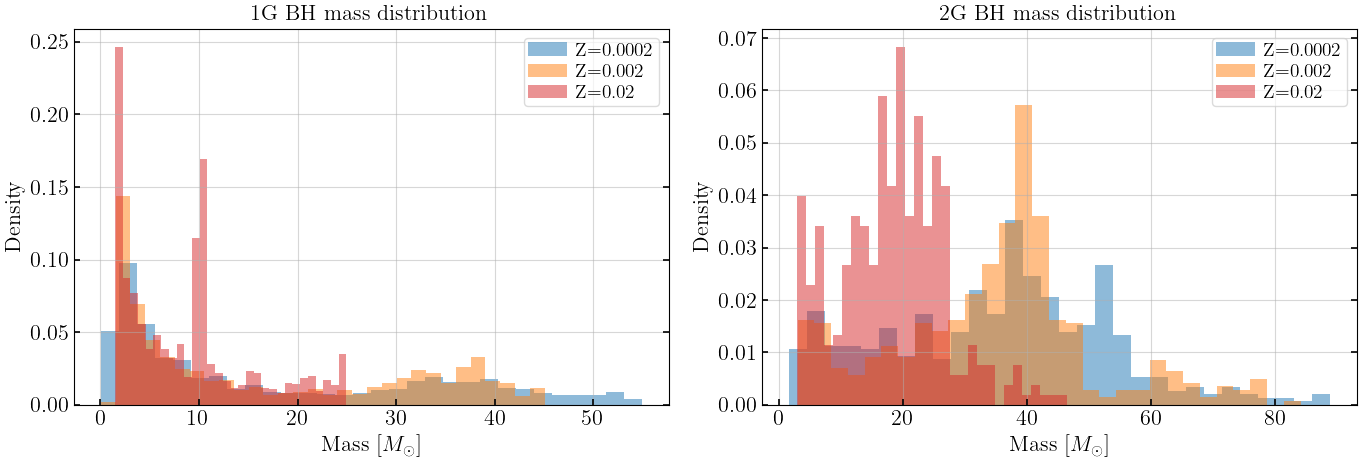

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_z = ['C0', 'C1', 'C3']

for Z, col in zip(metallicities, colors_z):
    d = z_results[Z]
    if len(d[1]['m']) > 1:
        axes[0].hist(d[1]['m'], bins=30, alpha=0.5, color=col,
                     label=f'Z={Z}', density=True)
    if len(d[2]['m']) > 1:
        axes[1].hist(d[2]['m'], bins=30, alpha=0.5, color=col,
                     label=f'Z={Z}', density=True)

axes[0].set_title('1G BH mass distribution')
axes[1].set_title('2G BH mass distribution')
for ax in axes:
    ax.set_xlabel('Mass [$M_\\odot$]')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Pairing model comparison

Compare random pairing vs mass-weighted pairing in a single massive cluster.

In [12]:
pairing_results = {}
for pairing in ['random', 'secondary_mass_power_law', 'total_mass_power_law']:
    sim_p = HierarchicalMergersInCluster(
        Mcl=1e6, rh=2.0, Z=0.005, max_gen=5,
        pairing=pairing, kick_model='gwmodel', seed=42)
    pairing_results[pairing] = sim_p.simulate()
    counts = [len(pairing_results[pairing][g]['m']) for g in range(1, 6)]
    print(f"{pairing:30s}: {counts}")

[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
random                        : [2946, 489, 117, 24, 9]
[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.


secondary_mass_power_law      : [2946, 466, 18, 1, 0]
[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
total_mass_power_law          : [2946, 609, 122, 19, 2]


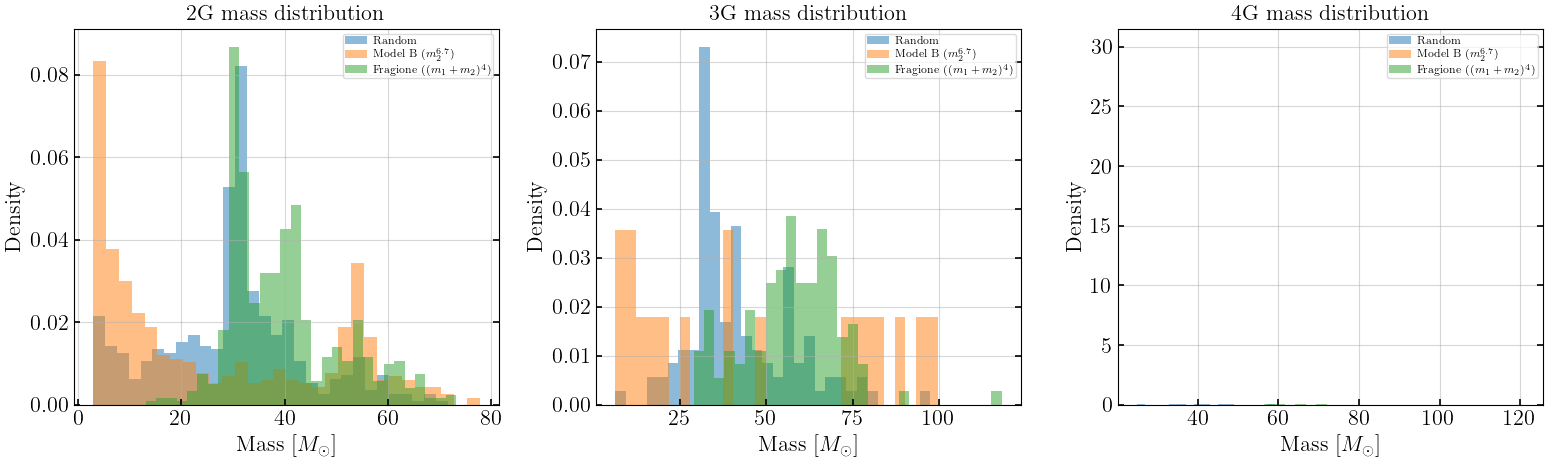

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = {'random': 'Random',
          'secondary_mass_power_law': 'Model B ($m_2^{6.7}$)',
          'total_mass_power_law': 'Fragione ($(m_1+m_2)^4$)'}

for ax, g in zip(axes, [2, 3, 4]):
    for pairing, col in zip(pairing_results, ['C0', 'C1', 'C2']):
        m = pairing_results[pairing][g]['m']
        if len(m) > 0:
            ax.hist(m, bins=30, alpha=0.5, color=col,
                    label=labels[pairing], density=True)
    ax.set_xlabel('Mass [$M_\\odot$]')
    ax.set_ylabel('Density')
    ax.set_title(f'{g}G mass distribution')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Kick model comparison (HLZ vs gwModel)

Use the 3-panel comparison plot to contrast HLZ and gwModel kick prescriptions.

In [14]:
sim_hlz = HierarchicalMergersInCluster(
    Mcl=1e6, rh=2.0, Z=0.005, max_gen=5,
    kick_model='hlz', seed=42)
data_hlz = sim_hlz.simulate(verbose=True)

sim_gw = HierarchicalMergersInCluster(
    Mcl=1e6, rh=2.0, Z=0.005, max_gen=5,
    kick_model='gwmodel', seed=42)
data_gw = sim_gw.simulate(verbose=True)

[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
1g: 2946 BHs (Mcl=1.0e+06 Msun, rh=2.0 pc, v_esc=58.7 km/s, Z=0.005, model=SEVN_delayed)
2g: 278 retained, m_med=30.7 Msun, chi_med=0.20
3g: 53 retained, m_med=38.4 Msun, chi_med=0.29
4g: 14 retained, m_med=45.8 Msun, chi_med=0.29
5g: 4 retained, m_med=45.0 Msun, chi_med=0.24
[HierarchicalMergersInCluster] No stellar_model specified — defaulting to 'SEVN_delayed'.
1g: 2946 BHs (Mcl=1.0e+06 Msun, rh=2.0 pc, v_esc=58.7 km/s, Z=0.005, model=SEVN_delayed)
2g: 489 retained, m_med=30.6 Msun, chi_med=0.28
3g: 117 retained, m_med=38.8 Msun, chi_med=0.34
4g: 24 retained, m_med=40.1 Msun, chi_med=0.32
5g: 9 retained, m_med=50.2 Msun, chi_med=0.42


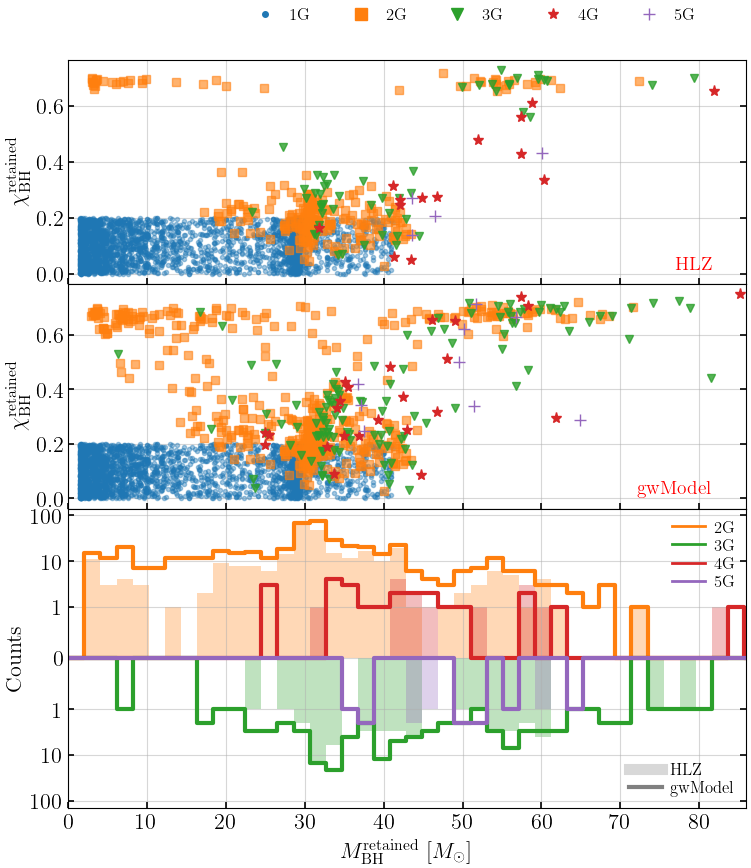

In [15]:
fig, axes = sim_hlz.plot_generations(
    data_hlz, compare_data=data_gw,
    label='HLZ', compare_label='gwModel')
plt.show()